In [ ]:
import numpy as np
import pandas as pd
!pip install ripser
!pip install persim
from ripser import ripser
import matplotlib.pyplot as plt
from persim import plot_diagrams

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.1 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=28be37c7e4e25c61b89987a87bc92eb68edaf866df52d650bddb749b9bc0677f
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [45]:
from dataclasses import dataclass

In [70]:
labels_df = pd.read_csv("/content/drive/MyDrive/557project/labels.csv")

In [4]:
original_df = pd.read_csv("/content/drive/MyDrive/557project/4columns_na_dropped.csv")

In [ ]:
@dataclass
class pd_result:
    labels_df: object
    original_df: object
    z_cols: list
    records: list
    pd_rips_result: list
    feature_df: object
    model_df: object
    model_betti_df: object

**Generate Persistent Diagram**

In [13]:
FEATURE_COLS = ["SKEW", "VIX", "Spread", "OAS"]

WINDOW_SIZE = 30
ROLLING_LOOKBACK = 126
EPS = 1e-8
MAX_HOMOLOGY_DIM = 1
THRESH = None


def causal_zscore(df, feature_cols, rolling_lookback=ROLLING_LOOKBACK, eps=1e-8):
    """
    copy the original_df and return a new dataframe with 4 new standardized columns
    input: dataframe
    output: dataframe
    """

    out = df.copy()

    for col in feature_cols:
        past_mean = out[col].shift(1).rolling(
            window=rolling_lookback,
            min_periods=rolling_lookback
        ).mean()
        past_std = out[col].shift(1).rolling(
            window=rolling_lookback,
            min_periods=rolling_lookback
        ).std()

        out[f"{col}_z"] = (out[col] - past_mean) / (past_std + eps)

    return out

In [14]:
z_df = causal_zscore(original_df, FEATURE_COLS)
print(z_df.head())

   Unnamed: 0        SKEW        VIX  Spread   OAS  SKEW_z  VIX_z  Spread_z  \
0  2000-01-05  114.820000  26.410000    0.24  4.77     NaN    NaN       NaN   
1  2000-01-06  114.870003  25.730000    0.22  4.82     NaN    NaN       NaN   
2  2000-01-07  117.349998  21.719999    0.21  4.86     NaN    NaN       NaN   
3  2000-01-10  115.730003  21.709999    0.19  4.81     NaN    NaN       NaN   
4  2000-01-11  114.980003  22.500000    0.22  4.74     NaN    NaN       NaN   

   OAS_z  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


In [23]:
print(z_df.iloc[141])

date        2000-07-27 00:00:00
SKEW                 113.279999
VIX                        19.6
Spread                    -0.25
OAS                        6.13
SKEW_z                 0.338231
VIX_z                 -1.360405
Spread_z               0.312101
OAS_z                  0.962231
Name: 141, dtype: object


In [20]:
z_df = z_df.rename(columns={"Unnamed: 0": "date"})
z_df["date"] = pd.to_datetime(z_df["date"])

In [21]:
def build_clouds(df, z_cols, window_size=WINDOW_SIZE, date_col="date"):
    """
    Shape of window is (30, 4). return a list
    input: z_df
    output: a list
    """
    records = []

    #  tranform to numpy array
    z_data = df[z_cols].to_numpy()
    dates = df[date_col].to_numpy()

    for t in range(window_size - 1, len(df)):
        window = z_data[t - window_size + 1 : t + 1]

        if np.isnan(window).any():
            continue

        records.append({
            "end_idx": t,
            "end_date": dates[t],
            "point_cloud": window
        })

    return records

In [24]:
records = build_clouds(z_df, FEATURE_COLS, WINDOW_SIZE, date_col="date")

In [25]:
print(records[:3])

[{'end_idx': 29, 'end_date': np.datetime64('2000-02-16T00:00:00.000000000'), 'point_cloud': array([[ 1.14820000e+02,  2.64099998e+01,  2.40000000e-01,
         4.77000000e+00],
       [ 1.14870003e+02,  2.57299995e+01,  2.20000000e-01,
         4.82000000e+00],
       [ 1.17349998e+02,  2.17199993e+01,  2.10000000e-01,
         4.86000000e+00],
       [ 1.15730003e+02,  2.17099991e+01,  1.90000000e-01,
         4.81000000e+00],
       [ 1.14980003e+02,  2.25000000e+01,  2.20000000e-01,
         4.74000000e+00],
       [ 1.14139999e+02,  2.28400002e+01,  2.30000000e-01,
         4.72000000e+00],
       [ 1.15180000e+02,  2.17099991e+01,  2.30000000e-01,
         4.82000000e+00],
       [ 1.16559998e+02,  1.96599998e+01,  2.50000000e-01,
         4.77000000e+00],
       [ 1.14379997e+02,  2.15000000e+01,  2.80000000e-01,
         4.75000000e+00],
       [ 1.15500000e+02,  2.17199993e+01,  2.70000000e-01,
         4.77000000e+00],
       [ 1.14800003e+02,  2.17500000e+01,  3.00000000e-01,

In [39]:
def compute_pd_rips(point_cloud, maxdim=1):
    result = ripser(point_cloud, maxdim=maxdim, distance_matrix=False)
    return result

In [29]:
first_cloud = records[2]["point_cloud"]

In [31]:
print(type(first_cloud))
print(first_cloud.shape)
print(first_cloud[:3])

<class 'numpy.ndarray'>
(30, 4)
[[117.34999847  21.71999931   0.21         4.86      ]
 [115.73000336  21.70999908   0.19         4.81      ]
 [114.98000336  22.5          0.22         4.74      ]]


In [32]:
# pd_rips_result = compute_pd_rips(first_cloud, maxdim=1)

In [40]:
def compute_all_window_pds(window_records, maxdim=1):
    out = []

    for rec in window_records:
        point_cloud = rec["point_cloud"]
        ripser_result = compute_pd_rips(point_cloud, maxdim=maxdim)

        out.append({
            "end_idx": rec["end_idx"],
            "end_date": rec["end_date"],
            "point_cloud": point_cloud,
            "dgms": ripser_result["dgms"],   # list: [H0_diag, H1_diag, ...]
            "ripser_result": ripser_result
        })

    return out

In [41]:
pd_rips_result = compute_all_window_pds(records, maxdim=1)

In [42]:
print(type(pd_rips_result))
print(len(pd_rips_result))
print(type(pd_rips_result[0]))
print(pd_rips_result[0].keys())

<class 'list'>
6430
<class 'dict'>
dict_keys(['end_idx', 'end_date', 'point_cloud', 'dgms', 'ripser_result'])


In [43]:
for i in range(3):
    rec = pd_rips_result[i]
    print(f"window {i}")
    print("end_date:", rec["end_date"])
    print("point_cloud shape:", rec["point_cloud"].shape)
    print("H0 shape:", rec["dgms"][0].shape)
    print("H1 shape:", rec["dgms"][1].shape)
    print("-" * 40)

window 0
end_date: 2000-02-16T00:00:00.000000000
point_cloud shape: (30, 4)
H0 shape: (30, 2)
H1 shape: (4, 2)
----------------------------------------
window 1
end_date: 2000-02-17T00:00:00.000000000
point_cloud shape: (30, 4)
H0 shape: (30, 2)
H1 shape: (2, 2)
----------------------------------------
window 2
end_date: 2000-02-18T00:00:00.000000000
point_cloud shape: (30, 4)
H0 shape: (30, 2)
H1 shape: (2, 2)
----------------------------------------


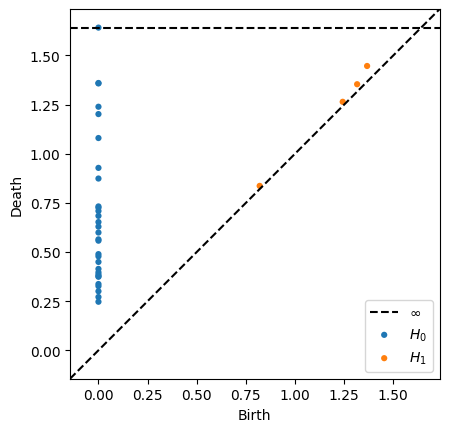

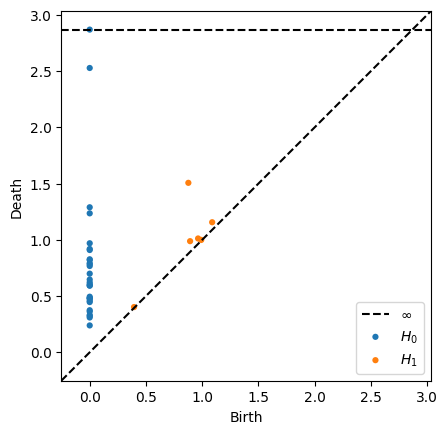

In [44]:
plot_diagrams(pd_rips_result[0]["dgms"], show=True)
plt.show()

plot_diagrams(pd_rips_result[100]["dgms"], show=True)
plt.show()

**Exploratory Analysis**



*   simple PD summaries
*   topology vectorization (not yet)



In [46]:
def safe_stats(arr):
    """
    arr: 1D numpy array
    return dict of safe summary stats
    """
    if len(arr) == 0:
        return {
            "count": 0,
            "sum": 0.0,
            "mean": 0.0,
            "max": 0.0,
            "std": 0.0
        }
    return {
        "count": len(arr),
        "sum": float(np.sum(arr)),
        "mean": float(np.mean(arr)),
        "max": float(np.max(arr)),
        "std": float(np.std(arr))
    }

def summarize_dgm(dgm, prefix="H"):
    """
    dgm: persistence diagram of shape (n_points, 2), columns = [birth, death]
    prefix: e.g. 'H0' or 'H1'
    """
    if dgm is None or len(dgm) == 0:
        births = np.array([])
        deaths = np.array([])
        pers = np.array([])
    else:
        births = dgm[:, 0]
        deaths = dgm[:, 1]

        # drop the point when death = inf
        finite_mask = np.isfinite(deaths)
        births = births[finite_mask]
        deaths = deaths[finite_mask]
        pers = deaths - births

    birth_stats = safe_stats(births)
    death_stats = safe_stats(deaths)
    pers_stats = safe_stats(pers)

    feat = {
        f"{prefix}_num_points": pers_stats["count"],

        f"{prefix}_birth_mean": birth_stats["mean"],
        f"{prefix}_birth_std": birth_stats["std"],

        f"{prefix}_death_mean": death_stats["mean"],
        f"{prefix}_death_std": death_stats["std"],

        f"{prefix}_pers_sum": pers_stats["sum"],
        f"{prefix}_pers_mean": pers_stats["mean"],
        f"{prefix}_pers_max": pers_stats["max"],
        f"{prefix}_pers_std": pers_stats["std"],
    }

    # top-k persistence
    if len(pers) > 0:
        sorted_pers = np.sort(pers)[::-1]
    else:
        sorted_pers = np.array([])

    for k in range(3):
        feat[f"{prefix}_top{k+1}_pers"] = float(sorted_pers[k]) if k < len(sorted_pers) else 0.0

    return feat

In [47]:
def vectorize_pd_rips_result(pd_rips_result):
    rows = []

    for rec in pd_rips_result:
        h0 = rec["dgms"][0]
        h1 = rec["dgms"][1]

        feat = {
            "end_idx": rec["end_idx"],
            "end_date": rec["end_date"],
        }

        feat.update(summarize_dgm(h0, prefix="H0"))
        feat.update(summarize_dgm(h1, prefix="H1"))

        rows.append(feat)

    return pd.DataFrame(rows)

feature_df = vectorize_pd_rips_result(pd_rips_result)
print(feature_df.head())
print(feature_df.shape)

   end_idx   end_date  H0_num_points  H0_birth_mean  H0_birth_std  \
0       29 2000-02-16             29            0.0           0.0   
1       30 2000-02-17             29            0.0           0.0   
2       31 2000-02-18             29            0.0           0.0   
3       32 2000-02-22             29            0.0           0.0   
4       33 2000-02-23             29            0.0           0.0   

   H0_death_mean  H0_death_std  H0_pers_sum  H0_pers_mean  H0_pers_max  ...  \
0       0.646215      0.325428    18.740232      0.646215     1.359964  ...   
1       0.624803      0.339545    18.119286      0.624803     1.359964  ...   
2       0.600549      0.310163    17.415907      0.600549     1.359964  ...   
3       0.619658      0.324107    17.970073      0.619658     1.359964  ...   
4       0.627953      0.300188    18.210645      0.627953     1.359964  ...   

   H1_birth_std  H1_death_mean  H1_death_std  H1_pers_sum  H1_pers_mean  \
0      0.215981       1.225298     

In [48]:
X_topo = feature_df.drop(columns=["end_idx", "end_date"])

print(X_topo.shape)
print(X_topo.isna().sum().sum())
print(X_topo.describe().T)

(6430, 24)
0
                count       mean        std        min        25%        50%  \
H0_num_points  6430.0  29.000000   0.000000  29.000000  29.000000  29.000000   
H0_birth_mean  6430.0   0.000000   0.000000   0.000000   0.000000   0.000000   
H0_birth_std   6430.0   0.000000   0.000000   0.000000   0.000000   0.000000   
H0_death_mean  6430.0   1.235502   0.524752   0.466138   0.877299   1.098872   
H0_death_std   6430.0   0.853245   0.477506   0.174189   0.506835   0.738904   
H0_pers_sum    6430.0  35.829557  15.217804  13.518005  25.441684  31.867290   
H0_pers_mean   6430.0   1.235502   0.524752   0.466138   0.877299   1.098872   
H0_pers_max    6430.0   4.020083   2.418313   0.904487   2.353669   3.336146   
H0_pers_std    6430.0   0.853245   0.477506   0.174189   0.506835   0.738904   
H0_top1_pers   6430.0   4.020083   2.418313   0.904487   2.353669   3.336146   
H0_top2_pers   6430.0   2.848089   1.408905   0.795608   1.800165   2.504575   
H0_top3_pers   6430.0   2.4

In [50]:
constant_cols = [col for col in X_topo.columns if X_topo[col].nunique() <= 1]
print("constant cols:", constant_cols)

constant cols: ['H0_num_points', 'H0_birth_mean', 'H0_birth_std']


In [52]:
X_topo_cleaned = X_topo.drop(columns=constant_cols).copy()
print(X_topo_cleaned.shape)

(6430, 21)


In [53]:
# for LR
X_topo_core = X_topo_cleaned.copy()

In [55]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df):
    X = df.copy()
    X = sm.add_constant(X)

    vif_df = pd.DataFrame()
    vif_df["feature"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_df.sort_values("VIF", ascending=False)

vif_df = compute_vif(X_topo_core)
print(vif_df)

          feature        VIF
1   H0_death_mean        inf
2    H0_death_std        inf
4    H0_pers_mean        inf
3     H0_pers_sum        inf
5     H0_pers_max        inf
6     H0_pers_std        inf
16   H1_pers_mean        inf
7    H0_top1_pers        inf
13  H1_death_mean        inf
11  H1_birth_mean        inf
17    H1_pers_max        inf
19   H1_top1_pers        inf
15    H1_pers_sum  99.175434
14   H1_death_std  37.753652
12   H1_birth_std  33.283308
18    H1_pers_std  21.891471
9    H0_top3_pers  16.888276
0           const  16.062584
8    H0_top2_pers  11.137233
20   H1_top2_pers  10.526833
21   H1_top3_pers   8.094464
10  H1_num_points   2.738369


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [ ]:
# select H1_num_points/H1_top2_pers/H0_top2_pers/H1_pers_std

In [68]:
original_df_lr = original_df.reset_index().rename(columns={"Unnamed: 0": "end_date"})
original_df_lr["end_date"] = pd.to_datetime(original_df_lr["end_date"], errors="coerce").dt.normalize()

print(original_df_lr.head())
print(original_df_lr.dtypes)

   level_0  index   end_date        SKEW        VIX  Spread   OAS
0        0      0 2000-01-05  114.820000  26.410000    0.24  4.77
1        1      1 2000-01-06  114.870003  25.730000    0.22  4.82
2        2      2 2000-01-07  117.349998  21.719999    0.21  4.86
3        3      3 2000-01-10  115.730003  21.709999    0.19  4.81
4        4      4 2000-01-11  114.980003  22.500000    0.22  4.74
level_0              int64
index                int64
end_date    datetime64[ns]
SKEW               float64
VIX                float64
Spread             float64
OAS                float64
dtype: object


In [69]:
# raw data + simple Topo summary
raw_simpleTopo_df = original_df_lr.merge(
    feature_df,
    left_on="end_date",
    right_on="end_date",
    how="inner"
)
print(raw_simpleTopo_df.head())
print(raw_simpleTopo_df.shape)

   level_0  index   end_date        SKEW        VIX  Spread   OAS  end_idx  \
0       29     29 2000-02-16  114.400002  23.510000   -0.07  4.86       29   
1       30     30 2000-02-17  114.760002  23.170000   -0.11  4.82       30   
2       31     31 2000-02-18  114.070000  26.000000   -0.17  4.90       31   
3       32     32 2000-02-22  112.470001  25.860001   -0.21  5.02       32   
4       33     33 2000-02-23  113.320000  23.889999   -0.17  4.94       33   

   H0_num_points  H0_birth_mean  ...  H1_birth_std  H1_death_mean  \
0             29            0.0  ...      0.215981       1.225298   
1             29            0.0  ...      0.211198       1.050452   
2             29            0.0  ...      0.211198       1.050452   
3             29            0.0  ...      0.325720       1.304325   
4             29            0.0  ...      0.325629       1.331946   

   H1_death_std  H1_pers_sum  H1_pers_mean  H1_pers_max  H1_pers_std  \
0      0.233509     0.155198      0.038800  

**Linear Regression**

*   Raw Data only

*   Simple Topo only
*   Raw + Topo




In [71]:
# labels
print(labels_df.head())

         Date  OFR FSI  Credit  Equity valuation  Safe assets  Funding  \
0  2000-01-03    2.140   0.540            -0.051        0.670    0.472   
1  2000-01-04    2.421   0.604             0.079        0.627    0.550   
2  2000-01-05    2.297   0.575             0.080        0.653    0.501   
3  2000-01-06    2.292   0.546             0.082        0.581    0.566   
4  2000-01-07    2.005   0.662            -0.011        0.519    0.565   

   Volatility  United States  Other advanced economies  Emerging markets  
0       0.509          1.769                     0.521            -0.150  
1       0.561          2.084                     0.474            -0.137  
2       0.488          2.023                     0.406            -0.132  
3       0.517          2.064                     0.355            -0.127  
4       0.270          1.769                     0.367            -0.131  


In [72]:
labels_lr = labels_df[["Date", "OFR FSI"]].copy()
labels_lr = labels_lr.rename(columns={"Date": "end_date", "OFR FSI": "ofr_fsi"})
labels_lr["end_date"] = pd.to_datetime(labels_lr["end_date"]).dt.normalize()

print(labels_lr.head())
print(labels_lr.dtypes)

    end_date  ofr_fsi
0 2000-01-03    2.140
1 2000-01-04    2.421
2 2000-01-05    2.297
3 2000-01-06    2.292
4 2000-01-07    2.005
end_date    datetime64[ns]
ofr_fsi            float64
dtype: object


In [73]:
model_df = raw_simpleTopo_df.merge(labels_lr, on="end_date", how="inner")

In [74]:
print(model_df.head())
print(model_df.shape)

   level_0  index   end_date        SKEW        VIX  Spread   OAS  end_idx  \
0       29     29 2000-02-16  114.400002  23.510000   -0.07  4.86       29   
1       30     30 2000-02-17  114.760002  23.170000   -0.11  4.82       30   
2       31     31 2000-02-18  114.070000  26.000000   -0.17  4.90       31   
3       32     32 2000-02-22  112.470001  25.860001   -0.21  5.02       32   
4       33     33 2000-02-23  113.320000  23.889999   -0.17  4.94       33   

   H0_num_points  H0_birth_mean  ...  H1_death_mean  H1_death_std  \
0             29            0.0  ...       1.225298      0.233509   
1             29            0.0  ...       1.050452      0.213908   
2             29            0.0  ...       1.050452      0.213908   
3             29            0.0  ...       1.304325      0.399259   
4             29            0.0  ...       1.331946      0.398404   

   H1_pers_sum  H1_pers_mean  H1_pers_max  H1_pers_std  H1_top1_pers  \
0     0.155198      0.038800     0.079693   

In [ ]:
# horizon = 5

In [75]:
# 3. future label
horizon = 5

model_df_future = model_df.copy()
model_df_future["future_ofr_fsi"] = model_df_future["ofr_fsi"].shift(-horizon)
model_df_future.dropna(subset=["future_ofr_fsi"])

,level_0,index,end_date,SKEW,VIX,Spread,OAS,end_idx,H0_num_points,H0_birth_mean,...,H1_death_std,H1_pers_sum,H1_pers_mean,H1_pers_max,H1_pers_std,H1_top1_pers,H1_top2_pers,H1_top3_pers,ofr_fsi,future_ofr_fsi
0,29,29,2000-02-16,114.400002,23.510000,-0.07,4.86,29,29,0.0,...,0.233509,0.155198,0.038800,0.079693,0.024882,0.079693,0.037606,0.021660,1.490,1.654
1,30,30,2000-02-17,114.760002,23.170000,-0.11,4.82,30,29,0.0,...,0.213908,0.037899,0.018950,0.021660,0.002711,0.021660,0.016239,0.000000,1.426,1.734
2,31,31,2000-02-18,114.070000,26.000000,-0.17,4.90,31,29,0.0,...,0.213908,0.037899,0.018950,0.021660,0.002711,0.021660,0.016239,0.000000,1.723,1.657
3,32,32,2000-02-22,112.470001,25.860001,-0.21,5.02,32,29,0.0,...,0.399259,0.232288,0.077429,0.194388,0.082732,0.194388,0.021660,0.016239,1.868,1.597
4,33,33,2000-02-23,113.320000,23.889999,-0.17,4.94,33,29,0.0,...,0.398404,0.356015,0.118672,0.194388,0.075143,0.194388,0.145388,0.016239,1.566,1.732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6417,6448,6448,2026-02-20,145.520004,19.090000,0.60,2.86,6448,29,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.527,-2.386
6418,6449,6449,2026-02-23,141.429993,21.010000,0.60,2.95,6449,29,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.396,-1.893
6419,6450,6450,2026-02-24,141.940002,19.549999,0.61,2.97,6450,29,0.0,...,0.000000,0.048402,0.048402,0.048402,0.000000,0.048402,0.000000,0.000000,-2.344,-1.610
6420,6451,6451,2026-02-25,146.050003,17.930000,0.60,2.94,6451,29,0.0,...,0.000000,0.048402,0.048402,0.048402,0.000000,0.048402,0.000000,0.000000,-2.601,-1.190


In [76]:
df_extreme_25 = model_df_future[
    (model_df_future["future_ofr_fsi"] < 0) | (model_df_future["future_ofr_fsi"] > 2.5)
].copy()

df_extreme_25["label"] = (df_extreme_25["future_ofr_fsi"] > 2.5).astype(int)

print(df_extreme_25["label"].value_counts())
print(df_extreme_25[["end_date", "ofr_fsi", "future_ofr_fsi", "label"]].head())

label
0    3998
1    1327
Name: count, dtype: int64
     end_date  ofr_fsi  future_ofr_fsi  label
25 2000-03-23    1.695           2.609      1
26 2000-03-24    1.888           2.971      1
27 2000-03-27    2.079           2.848      1
28 2000-03-28    2.212           3.008      1
29 2000-03-29    2.224           3.158      1


In [77]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix

def run_lr_time_split(df, feature_cols, label_col="label", split_ratio=0.8):
    split_idx = int(len(df) * split_ratio)

    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[label_col]
    X_test = test_df[feature_cols]
    y_test = test_df[label_col]

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced")
    )

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    print("Features:", feature_cols)
    print("Train size:", len(train_df), "Test size:", len(test_df))
    print("Train label counts:\n", y_train.value_counts())
    print("Test label counts:\n", y_test.value_counts())
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

    return clf

In [78]:
raw_cols = ["VIX", "SKEW", "Spread", "OAS"]
topo_cols = ["H1_num_points", "H1_top2_pers", "H0_top2_pers", "H1_pers_std"]

In [79]:
print("=== RAW ONLY ===")
clf_raw = run_lr_time_split(df_extreme_25, raw_cols)

print("\n=== TOPO ONLY ===")
clf_topo = run_lr_time_split(df_extreme_25, topo_cols)

print("\n=== RAW + TOPO ===")
clf_combined = run_lr_time_split(df_extreme_25, raw_cols + topo_cols)

=== RAW ONLY ===
Features: ['VIX', 'SKEW', 'Spread', 'OAS']
Train size: 4260 Test size: 1065
Train label counts:
 label
0    2962
1    1298
Name: count, dtype: int64
Test label counts:
 label
0    1036
1      29
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1036
           1       0.81      0.90      0.85        29

    accuracy                           0.99      1065
   macro avg       0.90      0.95      0.92      1065
weighted avg       0.99      0.99      0.99      1065

Accuracy: 0.9915492957746479
ROC-AUC: 0.9837238716549062
Confusion matrix:
 [[1030    6]
 [   3   26]]

=== TOPO ONLY ===
Features: ['H1_num_points', 'H1_top2_pers', 'H0_top2_pers', 'H1_pers_std']
Train size: 4260 Test size: 1065
Train label counts:
 label
0    2962
1    1298
Name: count, dtype: int64
Test label counts:
 label
0    1036
1      29
Name: count, dtype: int64

Classification report:
            

In [82]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_score, recall_score, f1_score
# calculate a threshold instead of using default

In [83]:
def select_threshold_time_cv(df, feature_cols, label_col="label", n_splits=5):
    X = df[feature_cols].reset_index(drop=True)
    y = df[label_col].reset_index(drop=True)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    thresholds = np.arange(0.3, 0.91, 0.05)

    records = []

    for thr in thresholds:
        fold_metrics = []

        for train_idx, val_idx in tscv.split(X):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            clf = make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=2000, class_weight="balanced")
            )
            clf.fit(X_train, y_train)

            y_prob = clf.predict_proba(X_val)[:, 1]
            y_pred = (y_prob >= thr).astype(int)

            fold_metrics.append({
                "precision": precision_score(y_val, y_pred, zero_division=0),
                "recall": recall_score(y_val, y_pred, zero_division=0),
                "f1": f1_score(y_val, y_pred, zero_division=0),
            })

        avg_precision = np.mean([m["precision"] for m in fold_metrics])
        avg_recall = np.mean([m["recall"] for m in fold_metrics])
        avg_f1 = np.mean([m["f1"] for m in fold_metrics])

        records.append({
            "threshold": thr,
            "precision": avg_precision,
            "recall": avg_recall,
            "f1": avg_f1,
        })

    result_df = pd.DataFrame(records).sort_values("f1", ascending=False)
    return result_df

In [84]:
threshold_results_raw = select_threshold_time_cv(df_extreme_25, raw_cols)
threshold_results_topo = select_threshold_time_cv(df_extreme_25, topo_cols)
threshold_results_raw_topo = select_threshold_time_cv(df_extreme_25, raw_cols+topo_cols)

print(threshold_results_raw)
print(threshold_results_topo)
print(threshold_results_raw_topo)

    threshold  precision    recall        f1
8        0.70   0.784708  0.951007  0.827696
7        0.65   0.774905  0.959094  0.823612
9        0.75   0.788256  0.925985  0.816011
6        0.60   0.758573  0.967928  0.813203
5        0.55   0.742887  0.971521  0.801024
10       0.80   0.792715  0.897821  0.800709
4        0.50   0.735092  0.976311  0.795287
3        0.45   0.725026  0.976311  0.786221
11       0.85   0.812050  0.853179  0.785240
2        0.40   0.714390  0.977212  0.776771
12       0.90   0.845050  0.807933  0.775739
1        0.35   0.705417  0.984108  0.771326
0        0.30   0.682739  0.984108  0.751166
    threshold  precision    recall        f1
2        0.40   0.162828  0.785033  0.223366
1        0.35   0.156826  0.855351  0.222026
3        0.45   0.167250  0.684695  0.220133
0        0.30   0.151584  0.939980  0.219525
4        0.50   0.176478  0.614432  0.219398
5        0.55   0.172802  0.483895  0.190341
6        0.60   0.196402  0.418251  0.187465
7        0

In [ ]:
# horizon = 10

In [85]:
horizon = 10

model_df_future = model_df.copy()
model_df_future["future_ofr_fsi"] = model_df_future["ofr_fsi"].shift(-horizon)
model_df_future.dropna(subset=["future_ofr_fsi"])

,level_0,index,end_date,SKEW,VIX,Spread,OAS,end_idx,H0_num_points,H0_birth_mean,...,H1_death_std,H1_pers_sum,H1_pers_mean,H1_pers_max,H1_pers_std,H1_top1_pers,H1_top2_pers,H1_top3_pers,ofr_fsi,future_ofr_fsi
0,29,29,2000-02-16,114.400002,23.510000,-0.07,4.86,29,29,0.0,...,0.233509,0.155198,0.038800,0.079693,0.024882,0.079693,0.037606,0.021660,1.490,1.541
1,30,30,2000-02-17,114.760002,23.170000,-0.11,4.82,30,29,0.0,...,0.213908,0.037899,0.018950,0.021660,0.002711,0.021660,0.016239,0.000000,1.426,1.284
2,31,31,2000-02-18,114.070000,26.000000,-0.17,4.90,31,29,0.0,...,0.213908,0.037899,0.018950,0.021660,0.002711,0.021660,0.016239,0.000000,1.723,1.512
3,32,32,2000-02-22,112.470001,25.860001,-0.21,5.02,32,29,0.0,...,0.399259,0.232288,0.077429,0.194388,0.082732,0.194388,0.021660,0.016239,1.868,1.909
4,33,33,2000-02-23,113.320000,23.889999,-0.17,4.94,33,29,0.0,...,0.398404,0.356015,0.118672,0.194388,0.075143,0.194388,0.145388,0.016239,1.566,2.019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6412,6443,6443,2026-02-12,142.500000,20.820000,0.62,2.92,6443,29,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.138,-2.386
6413,6444,6444,2026-02-13,139.350006,20.600000,0.64,2.95,6444,29,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.115,-1.893
6414,6445,6445,2026-02-17,140.279999,20.290001,0.62,2.94,6445,29,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.294,-1.610
6415,6446,6446,2026-02-18,139.169998,19.620001,0.62,2.86,6446,29,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.505,-1.190


In [87]:
df_extreme_25 = model_df_future[
    (model_df_future["future_ofr_fsi"] < 0) | (model_df_future["future_ofr_fsi"] > 2.5)
].copy()

df_extreme_25["label"] = (df_extreme_25["future_ofr_fsi"] > 2.5).astype(int)

print(df_extreme_25["label"].value_counts())
print(df_extreme_25[["end_date", "ofr_fsi", "future_ofr_fsi", "label"]].head())

label
0    3998
1    1327
Name: count, dtype: int64
     end_date  ofr_fsi  future_ofr_fsi  label
20 2000-03-16    1.981           2.609      1
21 2000-03-17    1.902           2.971      1
22 2000-03-20    1.974           2.848      1
23 2000-03-21    1.625           3.008      1
24 2000-03-22    1.623           3.158      1


In [88]:
print("=== RAW ONLY ===")
clf_raw = run_lr_time_split(df_extreme_25, raw_cols)

print("\n=== TOPO ONLY ===")
clf_topo = run_lr_time_split(df_extreme_25, topo_cols)

print("\n=== RAW + TOPO ===")
clf_combined = run_lr_time_split(df_extreme_25, raw_cols + topo_cols)

=== RAW ONLY ===
Features: ['VIX', 'SKEW', 'Spread', 'OAS']
Train size: 4260 Test size: 1065
Train label counts:
 label
0    2962
1    1298
Name: count, dtype: int64
Test label counts:
 label
0    1036
1      29
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1036
           1       0.55      0.83      0.66        29

    accuracy                           0.98      1065
   macro avg       0.77      0.90      0.82      1065
weighted avg       0.98      0.98      0.98      1065

Accuracy: 0.9765258215962441
ROC-AUC: 0.9742710690986554
Confusion matrix:
 [[1016   20]
 [   5   24]]

=== TOPO ONLY ===
Features: ['H1_num_points', 'H1_top2_pers', 'H0_top2_pers', 'H1_pers_std']
Train size: 4260 Test size: 1065
Train label counts:
 label
0    2962
1    1298
Name: count, dtype: int64
Test label counts:
 label
0    1036
1      29
Name: count, dtype: int64

Classification report:
            

In [ ]:
# betti curve

In [94]:
all_deaths = []

for rec in pd_rips_result:
    h1 = rec["dgms"][1]
    if h1 is not None and len(h1) > 0:
        deaths = h1[:, 1]
        deaths = deaths[np.isfinite(deaths)]
        all_deaths.extend(deaths.tolist())

all_deaths = np.array(all_deaths)

print("max:", all_deaths.max())
print("95% quantile:", np.quantile(all_deaths, 0.95))
print("99% quantile:", np.quantile(all_deaths, 0.99))

max: 15.83729076385498
95% quantile: 5.447268557548508
99% quantile: 8.240562438964844


In [95]:
import numpy as np
import pandas as pd

# 1) collect H1 finite deaths
all_h1_deaths = []

for rec in pd_rips_result:
    h1 = rec["dgms"][1]
    if h1 is None or len(h1) == 0:
        continue

    deaths = h1[:, 1]
    deaths = deaths[np.isfinite(deaths)]
    all_h1_deaths.extend(deaths.tolist())

all_h1_deaths = np.array(all_h1_deaths)

# 2) use 99% quantile as t_max
t_min = 0.0
t_max = np.quantile(all_h1_deaths, 0.99)
n_grid = 30
t_grid = np.linspace(t_min, t_max, n_grid)

print("H1 Betti grid:")
print("t_min =", t_min)
print("t_max (99% quantile) =", t_max)
print("n_grid =", n_grid)


# 3) Betti curve function
def compute_betti_curve(dgm, t_grid):
    if dgm is None or len(dgm) == 0:
        return np.zeros(len(t_grid), dtype=float)

    births = dgm[:, 0]
    deaths = dgm[:, 1]

    finite_mask = np.isfinite(deaths)
    births = births[finite_mask]
    deaths = deaths[finite_mask]

    if len(births) == 0:
        return np.zeros(len(t_grid), dtype=float)

    curve = []
    for t in t_grid:
        alive = np.sum((births <= t) & (t < deaths))
        curve.append(alive)

    return np.array(curve, dtype=float)


# 4) vectorize H1 Betti only
def vectorize_h1_betti_only(pd_rips_result, t_grid):
    rows = []

    for rec in pd_rips_result:
        h1 = rec["dgms"][1]
        h1_curve = compute_betti_curve(h1, t_grid)

        feat = {
            "end_idx": rec["end_idx"],
            "end_date": rec["end_date"],
        }

        for i, val in enumerate(h1_curve):
            feat[f"H1_betti_{i}"] = val

        rows.append(feat)

    return pd.DataFrame(rows)

betti_h1_df = vectorize_h1_betti_only(pd_rips_result, t_grid)
betti_h1_df["end_date"] = pd.to_datetime(betti_h1_df["end_date"]).dt.normalize()

print(betti_h1_df.head())
print(betti_h1_df.shape)

H1 Betti grid:
t_min = 0.0
t_max (99% quantile) = 8.240562438964844
n_grid = 30
   end_idx   end_date  H1_betti_0  H1_betti_1  H1_betti_2  H1_betti_3  \
0       29 2000-02-16         0.0         0.0         0.0         0.0   
1       30 2000-02-17         0.0         0.0         0.0         0.0   
2       31 2000-02-18         0.0         0.0         0.0         0.0   
3       32 2000-02-22         0.0         0.0         0.0         0.0   
4       33 2000-02-23         0.0         0.0         0.0         0.0   

   H1_betti_4  H1_betti_5  H1_betti_6  H1_betti_7  ...  H1_betti_20  \
0         0.0         1.0         0.0         0.0  ...          0.0   
1         0.0         0.0         0.0         0.0  ...          0.0   
2         0.0         0.0         0.0         0.0  ...          0.0   
3         0.0         0.0         1.0         0.0  ...          0.0   
4         0.0         0.0         1.0         0.0  ...          0.0   

   H1_betti_21  H1_betti_22  H1_betti_23  H1_betti_24 

In [100]:
model_betti_df = model_df.merge(betti_h1_df, on="end_date", how="inner")
model_betti_df = model_betti_df.merge(labels_lr, on="end_date", how="inner")
model_betti_df = model_betti_df.sort_values("end_date").reset_index(drop=True)

horizon = 10
model_betti_df["future_ofr_fsi"] = model_betti_df["ofr_fsi_y"].shift(-horizon)
model_betti_df = model_betti_df.dropna(subset=["future_ofr_fsi"]).copy()

df_extreme_betti = model_betti_df[
    (model_betti_df["future_ofr_fsi"] < 0) | (model_betti_df["future_ofr_fsi"] > 2.5)
].copy()

df_extreme_betti["label"] = (df_extreme_betti["future_ofr_fsi"] > 2.5).astype(int)

print(df_extreme_betti["label"].value_counts())

betti_cols = [c for c in df_extreme_betti.columns if c.startswith("H1_betti_")]

print("num betti features:", len(betti_cols))
print(betti_cols[:5], "...", betti_cols[-5:])

label
0    3998
1    1327
Name: count, dtype: int64
num betti features: 30
['H1_betti_0', 'H1_betti_1', 'H1_betti_2', 'H1_betti_3', 'H1_betti_4'] ... ['H1_betti_25', 'H1_betti_26', 'H1_betti_27', 'H1_betti_28', 'H1_betti_29']


In [101]:
print("=== RAW ONLY ===")
clf_raw = run_lr_time_split(df_extreme_betti, raw_cols)

print("\n=== H1 BETTI ONLY ===")
clf_betti = run_lr_time_split(df_extreme_betti, betti_cols)

print("\n=== RAW + H1 BETTI ===")
clf_raw_betti = run_lr_time_split(df_extreme_betti, raw_cols + betti_cols)

=== RAW ONLY ===
Features: ['VIX', 'SKEW', 'Spread', 'OAS']
Train size: 4260 Test size: 1065
Train label counts:
 label
0    2962
1    1298
Name: count, dtype: int64
Test label counts:
 label
0    1036
1      29
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1036
           1       0.55      0.83      0.66        29

    accuracy                           0.98      1065
   macro avg       0.77      0.90      0.82      1065
weighted avg       0.98      0.98      0.98      1065

Accuracy: 0.9765258215962441
ROC-AUC: 0.9742710690986554
Confusion matrix:
 [[1016   20]
 [   5   24]]

=== H1 BETTI ONLY ===
Features: ['H1_betti_0', 'H1_betti_1', 'H1_betti_2', 'H1_betti_3', 'H1_betti_4', 'H1_betti_5', 'H1_betti_6', 'H1_betti_7', 'H1_betti_8', 'H1_betti_9', 'H1_betti_10', 'H1_betti_11', 'H1_betti_12', 'H1_betti_13', 'H1_betti_14', 'H1_betti_15', 'H1_betti_16', 'H1_betti_17', 'H1_betti_18',